In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import numpy as np

In [ ]:
directory = "/atac/COLO"
mapped_counts = {}

# Read mapped counts from all files
for filename in os.listdir(directory):
    if filename.endswith(".txt"):
        filepath = os.path.join(directory, filename)
        with open(filepath) as f:
            for line in f:
                if re.match(r"^\d+ \+ \d+ mapped", line):
                    mapped_count = int(line.split()[0])
                    sample_name = filename.rsplit(".flagstat.txt", 1)[0]
                    mapped_counts[sample_name] = mapped_count
                    break

results = []
for sample in mapped_counts:
    # Only consider base samples (not filtered variants)
    if not sample.endswith(".filtered") and not sample.endswith(".filtered400"):
        base = mapped_counts.get(sample)
        filtered = mapped_counts.get(sample + ".filtered")
        filtered_400 = mapped_counts.get(sample + ".filtered400")
        if base is not None and filtered is not None and filtered_400 is not None:
            results.append({
                "sample": sample,
                "filtered_percent": filtered / base * 100,
                "filtered_400_percent": filtered_400 / base * 100
            })

df_filtered = pd.DataFrame(results)
print(df_filtered)

         sample  filtered_percent  filtered_400_percent
0  COLO829_rep1         68.350730             49.287614
1     COLO829BL         77.996679             60.827942
2  COLO829_rep2         70.985897             52.054227


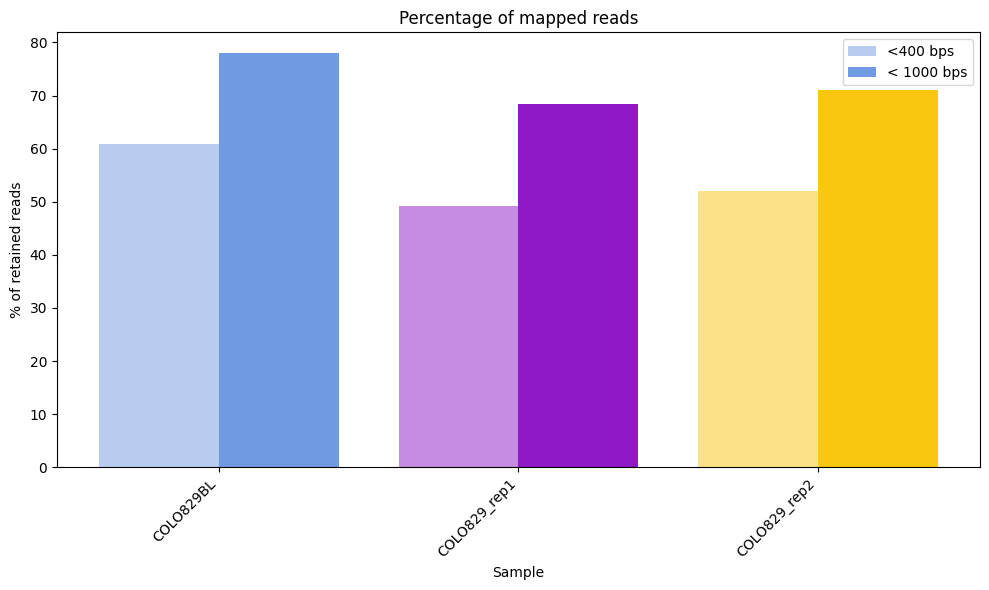

In [3]:


df_filtered_sorted = df_filtered.sort_values("sample")

timepoints_dict = {
    "COLO829BL" :"#709AE1FF",
    "COLO829_rep1" : "#8f18c7",
    "COLO829_rep2" : "#fac710"
}

samples = df_filtered_sorted['sample']
colors = [timepoints_dict.get(sample, "#cccccc") for sample in samples]

bar_width = 0.4
x = range(len(samples))

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], df_filtered_sorted["filtered_400_percent"], 
        width=bar_width, color=colors, label="<400 bps", alpha=0.5,)
plt.bar([i + bar_width/2 for i in x], df_filtered_sorted["filtered_percent"], 
        width=bar_width, color=colors,  label="< 1000 bps")  # More transparent

plt.xlabel("Sample")
plt.ylabel("% of retained reads")
plt.title("Percentage of mapped reads")
plt.xticks(x, samples, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("COLO-mapped_reads.pdf", bbox_inches='tight')
plt.show()

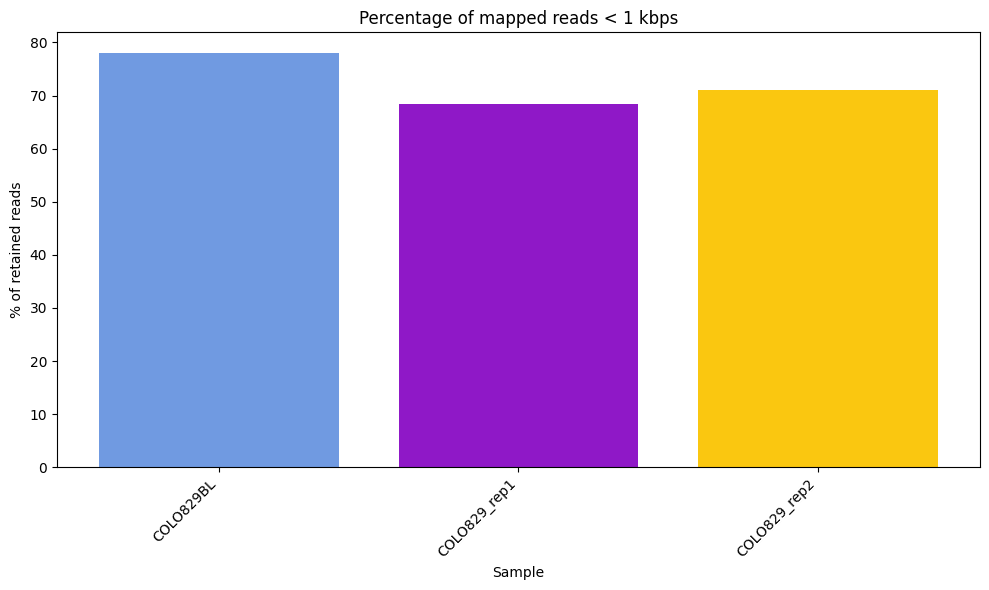

In [4]:
df_filtered_sorted = df_filtered.sort_values("sample")

timepoints_dict = {
    "COLO829BL" :"#709AE1FF",
    "COLO829_rep1" : "#8f18c7",
    "COLO829_rep2" : "#fac710"
}

colors = [timepoints_dict.get(sample, "#cccccc") for sample in df_filtered_sorted['sample']]

plt.figure(figsize=(10, 6))
plt.bar(df_filtered_sorted["sample"], df_filtered_sorted["filtered_percent"], color=colors)
plt.xlabel("Sample")
plt.ylabel("% of retained reads")
plt.title("Percentage of mapped reads < 1 kbps")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

      timepoint         <400        <1000           all
0     COLO829BL  24379062343  53674269748  252623949342
1  COLO829_rep1  20135999512  49833790908  290668704545
2  COLO829_rep2  23667726103  55886211968  280811734315


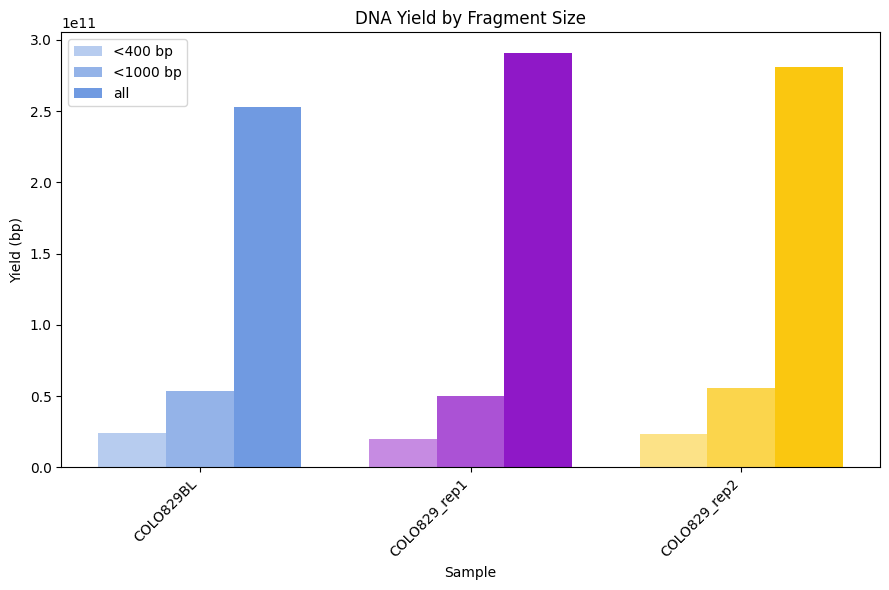

In [ ]:
import gzip

# DNA-only read length directory
dna_dir = '/SPLONGGET/figure_scripts/COLO/readlengths/DNA_lengths'

# Load and process read lengths
read_length_data = []

for filename in os.listdir(dna_dir):
    # Skip files with "_bam" in the name
    if "_bam" in filename or not filename.endswith(".txt.gz"):
        continue

    # Extract timepoint from filename (e.g., "D0_read_lengths.txt.gz" -> "D0")
    timepoint = filename.replace("_read_lengths.txt.gz", "")

    # Load read lengths
    filepath = os.path.join(dna_dir, filename)
    with gzip.open(filepath, 'rt') as f:
        lengths = [int(line.strip()) for line in f if line.strip()]

    read_length_data.append({
        'timepoint': timepoint,
        '<400': sum(l for l in lengths if l < 400),
        '<1000': sum(l for l in lengths if l < 1000),
        'all': sum(lengths)
    })

df_read_lengths = pd.DataFrame(read_length_data)

# Sum per timepoint (robust if multiple files per timepoint are present)
df_read_lengths = df_read_lengths.groupby('timepoint', as_index=False)[['<400', '<1000', 'all']].sum()
print(df_read_lengths)

# Create grouped bar plot for DNA read length analysis
timepoints_dict = {
    "COLO829BL" :"#709AE1FF",
    "COLO829_rep1" : "#8f18c7",
    "COLO829_rep2" : "#fac710"
}

timepoint_order = ["COLO829BL", "COLO829_rep1", "COLO829_rep2"]
df_read_lengths['timepoint'] = pd.Categorical(df_read_lengths['timepoint'], categories=timepoint_order, ordered=True)
df_plot = df_read_lengths.sort_values('timepoint')

x = np.arange(len(df_plot))
bar_width = 0.25
colors = [timepoints_dict.get(tp, "#cccccc") for tp in df_plot['timepoint']]

fig, ax = plt.subplots(figsize=(9, 6))

# Plot <400 bars (left)
ax.bar(
    x - bar_width,
    df_plot['<400'],
    width=bar_width,
    color=colors,
    label='<400 bp',
    alpha=0.5
)

# Plot <1000 bars (center)
ax.bar(
    x,
    df_plot['<1000'],
    width=bar_width,
    color=colors,
    label='<1000 bp',
    alpha=0.75
)

# Plot all bars (right)
ax.bar(
    x + bar_width,
    df_plot['all'],
    width=bar_width,
    color=colors,
    label='all',
    alpha=1.0
)

ax.set_xticks(x)
ax.set_xticklabels(df_plot['timepoint'], rotation=45, ha='right')
ax.set_xlabel('Sample')
ax.set_ylabel('Yield (bp)')
ax.set_title('DNA Yield by Fragment Size')
ax.legend()

plt.tight_layout()
plt.savefig("COLO-dna_yield.pdf", bbox_inches='tight')

plt.show()

In [12]:
pip list 

Package                              Version
------------------------------------ -----------------
adjustText                           1.0.4
aiohttp                              3.9.3
aiosignal                            1.3.1
anndata                              0.10.5.post1
annoy                                1.17.3
appdirs                              1.4.4
arboreto                             0.1.6
argparse-dataclass                   2.0.0
array_api_compat                     1.5.1
asttokens                            2.4.1
attr                                 0.3.2
attrs                                23.2.0
bbknn                                1.6.0
beautifulsoup4                       4.12.3
bidict                               0.23.1
bioservices                          1.11.2
blosc2                               2.5.1
bokeh                                3.4.0
boltons                              23.1.1
bs4                                  0.0.2
cattrs                     